In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
df = pd.read_csv("solar_system.csv")

print(df.shape)
print(df.head())
display(df.head())
display(df.tail())
print(df.columns.tolist())
print(df.index.tolist())


(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune', 'Pluto']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [10]:
orbital_period = df.loc["Orbital Period (days)"].astype(float).values
perihelion = df.loc["Perihelion (10^6 km)"].astype(float).values
aphelion = df.loc["Aphelion (10^6 km)"].astype(float).values

In [14]:
semi_major_axis = (perihelion + aphelion) / 2

'''
Perihelion: the point/distance in the orbit closest to the sun
Aphelion: the point/distance in the orbit furthest from the sun
Semi-major axis: half of the sum of perhelion and aphelion
'''


'\nPerihelion: the point/distance in the orbit closest to the sun\nAphelion: the point/distance in the orbit furthest from the sun\nSemi-major axis: half of the sum of perhelion and aphelion\n'

In [15]:
sma_series = pd.Series(
    semi_major_axis,
    index=df.columns,
    name="Semi-major axis (10^6 km)"
)

dfnew = pd.concat([df, sma_series.to_frame().T])

print(dfnew.shape)

(21, 10)


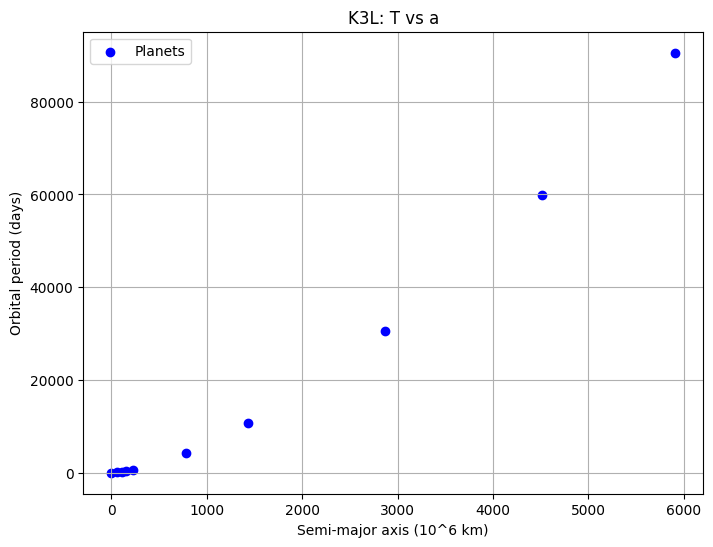

In [17]:
a = dfnew.loc["Semi-major axis (10^6 km)"].astype(float).values
T = dfnew.loc["Orbital Period (days)"].astype(float).values

plt.figure(figsize=(8,6))
plt.scatter(a, T, color="blue", label="Planets")

plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (days)")
plt.title("K3L: T vs a")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
def keplers_third_law(a, m):
    return m*a **1.5

popt, pcov = curve_fit(keplers_third_law, a, T, p0=[1])
m_fit = popt[0]
print(f"Fit: T = {m_fit:.2f} * a^(3/2)")



Fit: T = 0.20 * a^(3/2)


In [21]:
residuals = T - keplers_third_law(a, m_fit)
chi2 = np.sum(residuals**2)
dof = len(a) - 1
chi2_reduced = chi2 / dof
chi2_reduced


np.float64(41276.70608939304)

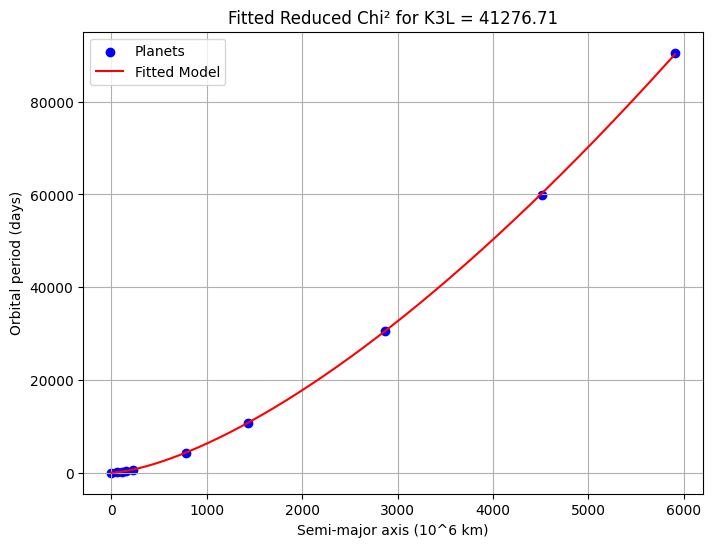

In [23]:
plt.figure(figsize=(8,6))


plt.scatter(a, T, color="blue", label="Planets")

# Fitted model curve
a_fit = np.linspace(min(a), max(a), 500)
plt.plot(a_fit, keplers_third_law(a_fit, m_fit),
         color="red", label="Fitted Model")

plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (days)")
plt.title(f"Fitted Reduced Chi² for K3L = {chi2_reduced:.2f}")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
dfnew.to_csv("kepler.csv")